## **AIRLINE FLIGHT DELAY ANALYSIS USING EXPLORATORY DATA ANALYSIS**

**INTRODUCTION:**

This project analyzes airline flight data to identify patterns and factors responsible for flight delays and cancellations.
Using Exploratory Data Analysis (EDA), we compare airlines, airports, routes, time periods, and delay causes to generate actionable business insights.

**PROBLEM STATEMENT:**

Airline flight delays are a major challenge affecting passengers and airline operations.
Delays can occur due to weather, airline issues, air traffic, security, and late-arriving aircraft.
This project analyzes historical flight data to understand delay patterns.
It compares the performance of different airlines and airports.
The analysis also examines routes, time periods, and cancellation patterns.
Different causes of flight delays are identified and analyzed.
EDA techniques are used to discover meaningful patterns and trends.

"The findings provide insights to reduce delays and improve airline efficiency."

“Better data leads to better decisions and better journeys.”

**OBJECTIVE OF THE PROJECT:**

The objective of this project is to perform EDA(Exploratory Data Analysis) analyze airline flight data and identify the major factors contributing to flight delays and cancellations. The project aims to compare the performance of different airlines, airports, routes, and time periods, while analyzing various causes of delays such as weather, airline issues, air traffic, and late-arriving aircraft. The analysis will generate meaningful data-driven insights and recommendations to help airlines reduce delays, improve operational efficiency, and enhance passenger satisfaction.

**BUSINESS QUESTIONS**

1.What percentage of flights are delayed or on time?

2.Which airline has the highest flight delay rate?

3.Which airline has the lowest flight delay rate?

4.Which routes experience the highest number of delays?

5.Is there a relationship between departure delay and arrival delay?

6.Does flight distance have an impact on arrival delays?

7.What are the major causes of flight delays?

8.What are the most common reasons for flight cancellations?

**DATA UNDERSTANDING:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("flights.csv")

In [4]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


**Observations:**

* The dataset has total 1048575 rows and 31 columns.
* The dataset provides comprehensive flight information, including airline, route, timing, distance, delays, cancellations, and delay causes.
* It can be effectively used to identify patterns in flight delays and generate actionable insights for improving airline operational efficiency.
* Categorical Data: AIRLINE, ORIGIN_AIRPORT, DESTINATION_AIRPORT, DAY_NAME, MONTH_NAME, FLIGHT_STATUS, and CANCELLATION_REASON.
* Real Numeriacal Data: DEPARTURE_DELAY, ARRIVAL_DELAY, DISTANCE, AIR_TIME, TAXI_OUT, TAXI_IN, ELAPSED_TIME.
* Discrete Numerical Data: YEAR, MONTH, DAY, DAY_OF_WEEK, FLIGHT_NUMBER, SCHEDULED_DEPARTURE, SCHEDULED_ARRIVAL, CANCELLED

In [5]:
df.shape

(1048575, 31)

In [6]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 31 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   YEAR                 1048575 non-null  int64  
 1   MONTH                1048575 non-null  int64  
 2   DAY                  1048575 non-null  int64  
 3   DAY_OF_WEEK          1048575 non-null  int64  
 4   AIRLINE              1048575 non-null  object 
 5   FLIGHT_NUMBER        1048575 non-null  int64  
 6   TAIL_NUMBER          1040825 non-null  object 
 7   ORIGIN_AIRPORT       1048575 non-null  object 
 8   DESTINATION_AIRPORT  1048575 non-null  object 
 9   SCHEDULED_DEPARTURE  1048575 non-null  int64  
 10  DEPARTURE_TIME       1009060 non-null  float64
 11  DEPARTURE_DELAY      1009060 non-null  float64
 12  TAXI_OUT             1008346 non-null  float64
 13  WHEELS_OFF           1008346 non-null  float64
 14  SCHEDULED_TIME       1048573 non-null  float64
 15

In [9]:
df.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [11]:
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,1048575.0,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.009060e+06,1.009060e+06,1.008346e+06,1.008346e+06,1.048573e+06,1.005504e+06,1.005504e+06,1.048575e+06,1.007279e+06,1.007279e+06,1.048575e+06,1.007279e+06,1.005504e+06,1.048575e+06,1.048575e+06,228528.000000,228528.000000,228528.000000,228528.000000,228528.000000
mean,2015.0,1.694297e+00,1.382097e+01,3.953196e+00,2.256759e+03,1.322632e+03,1.333705e+03,1.133485e+01,1.665380e+01,1.357382e+03,1.402526e+02,1.369381e+02,1.127477e+02,8.034077e+02,1.485932e+03,7.549438e+00,1.504820e+03,1.492204e+03,7.612191e+00,2.426150e-03,3.864960e-02,13.692554,0.057328,18.203577,22.921458,3.545277
std,0.0,7.051508e-01,8.725656e+00,1.999436e+00,1.799166e+03,4.707748e+02,4.827415e+02,3.922372e+01,1.007006e+01,4.830351e+02,7.463458e+01,7.394818e+01,7.186952e+01,5.942362e+02,5.033515e+02,6.352526e+00,4.865613e+02,5.071090e+02,4.209367e+01,4.919620e-02,1.927585e-01,25.524897,1.779647,46.323146,41.888498,23.611555
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-6.100000e+01,1.000000e+00,1.000000e+00,2.000000e+01,1.500000e+01,7.000000e+00,3.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.0,1.000000e+00,6.000000e+00,2.000000e+00,7.550000e+02,9.200000e+02,9.280000e+02,-5.000000e+00,1.100000e+01,9.440000e+02,8.500000e+01,8.200000e+01,6.000000e+01,3.680000e+02,1.110000e+03,4.000000e+00,1.120000e+03,1.115000e+03,-1.200000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015.0,2.000000e+00,1.300000e+01,4.000000e+00,1.725000e+03,1.319000e+03,1.329000e+03,-1.000000e+00,1.400000e+01,1.342000e+03,1.220000e+02,1.190000e+02,9.400000e+01,6.410000e+02,1.516000e+03,6.000000e+00,1.524000e+03,1.521000e+03,-3.000000e+00,0.000000e+00,0.000000e+00,4.000000,0.000000,2.000000,4.000000,0.000000
75%,2015.0,2.000000e+00,2.100000e+01,6.000000e+00,3.485000e+03,1.720000e+03,1.731000e+03,1.100000e+01,1.900000e+01,1.745000e+03,1.730000e+02,1.690000e+02,1.440000e+02,1.046000e+03,1.911000e+03,9.000000e+00,1.915000e+03,1.917000e+03,1.200000e+01,0.000000e+00,0.000000e+00,19.000000,0.000000,18.000000,29.000000,0.000000
max,2015.0,3.000000e+00,3.100000e+01,7.000000e+00,9.794000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,7.180000e+02,7.660000e+02,6.870000e+02,4.983000e+03,2.400000e+03,2.020000e+02,2.359000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,830.000000,241.000000,1971.000000,1313.000000,1152.000000


**Data Cleaning**

In [14]:
#Verifying duplicates
df.duplicated().sum()

np.int64(0)

**Observations:**

* There are 0 duplicate records in the dataset. the dataset does not contain any duplicate rows and no duplicate records need to be removed.

In [15]:
#Dropping Duplicate values
df = df.drop_duplicates()
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2015,3,10,2,EV,4122,N11191,RDU,EWR,1013,1005.0,-8.0,17.0,1022.0,96.0,88.0,64.0,416,1126.0,7.0,1149,1133.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1048571,2015,3,10,2,UA,1018,N79279,LGA,IAH,1013,1005.0,-8.0,40.0,1045.0,264.0,270.0,219.0,1416,1324.0,11.0,1337,1335.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1048572,2015,3,10,2,UA,1260,N76508,SAN,ORD,1013,1010.0,-3.0,21.0,1031.0,251.0,257.0,220.0,1723,1611.0,16.0,1624,1627.0,3.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1048573,2015,3,10,2,EV,4349,N14158,MSY,ORD,1013,1003.0,-10.0,10.0,1013.0,149.0,146.0,127.0,837,1220.0,9.0,1242,1229.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
#Verifying missing values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

CANCELLATION_REASON    1008048
WEATHER_DELAY           820047
LATE_AIRCRAFT_DELAY     820047
AIRLINE_DELAY           820047
SECURITY_DELAY          820047
AIR_SYSTEM_DELAY        820047
ELAPSED_TIME             43071
AIR_TIME                 43071
ARRIVAL_DELAY            43071
ARRIVAL_TIME             41296
TAXI_IN                  41296
WHEELS_ON                41296
WHEELS_OFF               40229
TAXI_OUT                 40229
DEPARTURE_TIME           39515
DEPARTURE_DELAY          39515
TAIL_NUMBER               7750
SCHEDULED_TIME               2
dtype: int64

**Observations:**
* CANCELLATION_REASON has the highest missing values.
* ARRIVAL_DELAY has 43,071 missing values.
* DEPARTURE_DELAY has 39,515 missing values.
* TAIL_NUMBER has 7,750 missing values.
* SCHEDULED_TIME has only 2 missing values.
* Missing values need to be treated carefully before analysis.

In [19]:
#Missing values for percentages
missing_percentage = (df.isnull().sum() / len(df))*100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

CANCELLATION_REASON    96.135040
WEATHER_DELAY          78.205851
LATE_AIRCRAFT_DELAY    78.205851
AIRLINE_DELAY          78.205851
SECURITY_DELAY         78.205851
AIR_SYSTEM_DELAY       78.205851
ELAPSED_TIME            4.107575
AIR_TIME                4.107575
ARRIVAL_DELAY           4.107575
ARRIVAL_TIME            3.938297
TAXI_IN                 3.938297
WHEELS_ON               3.938297
WHEELS_OFF              3.836540
TAXI_OUT                3.836540
DEPARTURE_TIME          3.768448
DEPARTURE_DELAY         3.768448
TAIL_NUMBER             0.739098
SCHEDULED_TIME          0.000191
dtype: float64

**Observations:**

* CANCELLATION_REASON has the highest missing percentage (96.14%).
* Delay-cause columns have 78.21% missing values.
* ARRIVAL_DELAY has 4.11% missing values.
* DEPARTURE_DELAY has 3.77% missing values.
* TAIL_NUMBER has only 0.74% missing values.
* SCHEDULED_TIME has very few missing values (0.0002%).
* Missing values should be handled appropriately before further analysis.

**Create Useful Columns**

In [24]:
#Creating Date column
df['DATE'] = pd.to_datetime(
    df[['YEAR', 'MONTH', 'DAY']]
)
df['DATE']

0         2015-01-01
1         2015-01-01
2         2015-01-01
3         2015-01-01
4         2015-01-01
             ...    
1048570   2015-03-10
1048571   2015-03-10
1048572   2015-03-10
1048573   2015-03-10
1048574   2015-03-10
Name: DATE, Length: 1048575, dtype: datetime64[ns]

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 32 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   YEAR                 1048575 non-null  int64         
 1   MONTH                1048575 non-null  int64         
 2   DAY                  1048575 non-null  int64         
 3   DAY_OF_WEEK          1048575 non-null  int64         
 4   AIRLINE              1048575 non-null  object        
 5   FLIGHT_NUMBER        1048575 non-null  int64         
 6   TAIL_NUMBER          1040825 non-null  object        
 7   ORIGIN_AIRPORT       1048575 non-null  object        
 8   DESTINATION_AIRPORT  1048575 non-null  object        
 9   SCHEDULED_DEPARTURE  1048575 non-null  int64         
 10  DEPARTURE_TIME       1009060 non-null  float64       
 11  DEPARTURE_DELAY      1009060 non-null  float64       
 12  TAXI_OUT             1008346 non-null  float64       
 1

In [22]:
#Creating month_name column
df['MONTH_NAME'] = df['DATE'].dt.month_name()
df['MONTH_NAME']

0          January
1          January
2          January
3          January
4          January
            ...   
1048570      March
1048571      March
1048572      March
1048573      March
1048574      March
Name: MONTH_NAME, Length: 1048575, dtype: object

In [23]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,MONTH_NAME
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,January
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,January
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,January
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,January
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,January


In [25]:
#Creating Day_name column
df['DAY_NAME'] = df['DATE'].dt.day_name()
df['DAY_NAME']

0          Thursday
1          Thursday
2          Thursday
3          Thursday
4          Thursday
             ...   
1048570     Tuesday
1048571     Tuesday
1048572     Tuesday
1048573     Tuesday
1048574     Tuesday
Name: DAY_NAME, Length: 1048575, dtype: object

In [26]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,MONTH_NAME,DAY_NAME
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,January,Thursday
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,January,Thursday
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,January,Thursday
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,January,Thursday
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,January,Thursday


In [27]:
#Creating a flight status
df['FLIGHT_STATUS'] = np.where(
    df['ARRIVAL_DELAY'] > 0,
    'Delayed',
    'On Time'
)
df['FLIGHT_STATUS'].value_counts()

FLIGHT_STATUS
On Time    624446
Delayed    424129
Name: count, dtype: int64

**Observations:**

* 624,446 flights were On Time.
* 424,129 flights were Delayed.
* On-time flights are higher than delayed flights.

In [28]:
#percentage
df['FLIGHT_STATUS'].value_counts(normalize=True)*100

FLIGHT_STATUS
On Time    59.551868
Delayed    40.448132
Name: proportion, dtype: float64

**Observations:**

* Approximately 59.54% of flights were on time.
* Approximately 40.46% of flights were delayed.
* This indicates that a significant proportion of flights experienced delays.

**Visualizations:**

**Univariate Analysis**



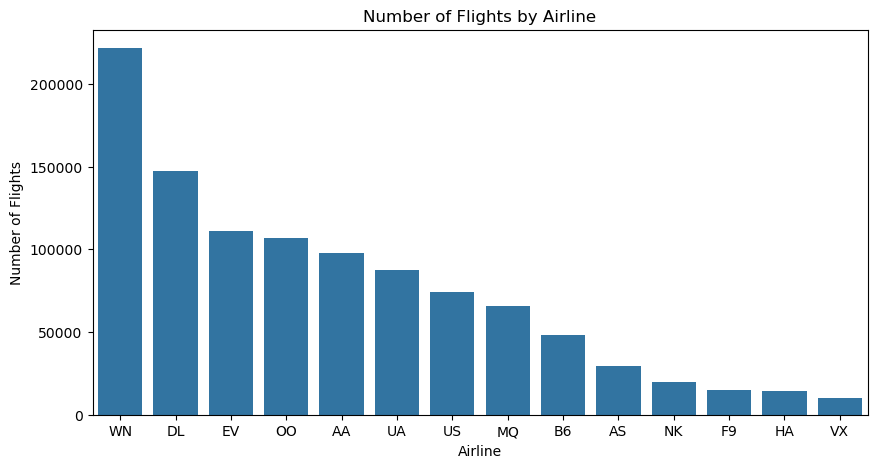

In [41]:
#Flights by Airline
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='AIRLINE',
    order=df['AIRLINE'].value_counts().index
)
plt.title('Number of Flights by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Flights')
plt.show()

In [35]:
#Which airline operates the highest number of flights?
df['AIRLINE'].value_counts().idxmax()

'WN'

In [36]:
#Which airline operates the lowest number of flights?
df['AIRLINE'].value_counts().idxmin()

'VX'

In [37]:
#How many flights are operated by each airline?
df['AIRLINE'].value_counts()

AIRLINE
WN    221586
DL    147486
EV    111206
OO    107099
AA     97549
UA     87606
US     73942
MQ     65513
B6     48157
AS     29614
NK     19612
F9     14669
HA     14133
VX     10403
Name: count, dtype: int64

In [38]:
#Which are the top 5 airlines based on flight count?
df['AIRLINE'].value_counts().head(5)

AIRLINE
WN    221586
DL    147486
EV    111206
OO    107099
AA     97549
Name: count, dtype: int64

In [39]:
#Which airlines have fewer than 60,000 flights?
df['AIRLINE'].value_counts()[lambda x: x < 60000]

AIRLINE
B6    48157
AS    29614
NK    19612
F9    14669
HA    14133
VX    10403
Name: count, dtype: int64

**Observations:**

* WN has the highest number of flights, with approximately 225,000+ flights.
* DL is the second-highest airline, with around 150,000+ flights.
* EV, OO, and AA have a relatively high number of flights, each with 100,000+ flights.
* UA, US, and MQ have a moderate number of flights.
* VX has one of the lowest numbers of flights, along with HA, F9, and NK.
* There is a large difference in flight volume between WN and the smaller airlines.
* The chart shows that a few major airlines handle a large proportion of the total flights.

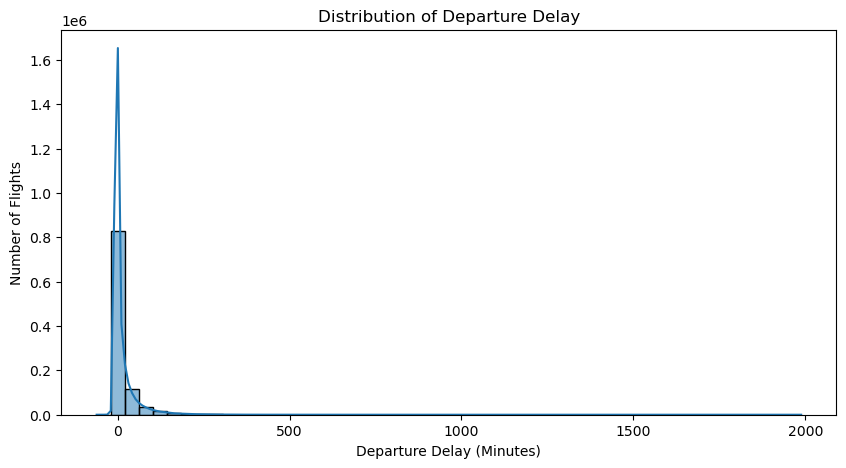

In [45]:
#Departure Delay Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['DEPARTURE_DELAY'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Departure Delay')
plt.xlabel('Departure Delay (Minutes)')
plt.ylabel('Number of Flights')
plt.show()

In [47]:
#What is the average,median departure delay?
df['DEPARTURE_DELAY'].mean()

np.float64(11.334851247695875)

In [48]:
df['DEPARTURE_DELAY'].median()

-1.0

In [49]:
#What percentage of flights have zero departure delay?
(df['DEPARTURE_DELAY'].eq(0).mean()*100)

np.float64(5.206208425720621)

In [50]:
#What percentage of flights are delayed at departure?
(df['DEPARTURE_DELAY'].gt(0).mean()*100)

np.float64(39.77531411677753)

In [51]:
#Are there significant outliers in departure delay?
q1=df['DEPARTURE_DELAY'].quantile(.25)
q3=df['DEPARTURE_DELAY'].quantile(.75)
iqr=q3-q1
df[df['DEPARTURE_DELAY']>q3+1.5*iqr]


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,MONTH_NAME,DAY_NAME,FLIGHT_STATUS
30,2015,1,1,4,NK,168,N629NK,PHX,ORD,125,237.0,72.0,9.0,246.0,204.0,175.0,156.0,1440,622.0,10.0,549,632.0,43.0,0,0,NaN,43.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Delayed
52,2015,1,1,4,B6,2134,N307JB,SJU,MCO,400,535.0,95.0,9.0,544.0,185.0,175.0,163.0,1189,727.0,3.0,605,730.0,85.0,0,0,NaN,0.0,0.0,85.0,0.0,0.0,2015-01-01,January,Thursday,Delayed
55,2015,1,1,4,B6,2276,N646JB,SJU,BDL,438,550.0,72.0,15.0,605.0,241.0,258.0,237.0,1666,902.0,6.0,739,908.0,89.0,0,0,NaN,17.0,0.0,72.0,0.0,0.0,2015-01-01,January,Thursday,Delayed
70,2015,1,1,4,AA,1057,N3ASAA,DFW,MIA,515,703.0,108.0,15.0,718.0,161.0,155.0,133.0,1121,1031.0,7.0,856,1038.0,102.0,0,0,NaN,0.0,0.0,0.0,0.0,102.0,2015-01-01,January,Thursday,Delayed
73,2015,1,1,4,US,425,N174US,PDX,PHX,520,620.0,60.0,13.0,633.0,150.0,150.0,132.0,1009,945.0,5.0,850,950.0,60.0,0,0,NaN,0.0,0.0,60.0,0.0,0.0,2015-01-01,January,Thursday,Delayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048533,2015,3,10,2,WN,2404,N794SW,MDW,MCO,1010,1144.0,94.0,5.0,1149.0,150.0,157.0,136.0,990,1505.0,16.0,1340,1521.0,101.0,0,0,NaN,7.0,0.0,92.0,2.0,0.0,2015-03-10,March,Tuesday,Delayed
1048534,2015,3,10,2,WN,449,N8603F,BWI,ISP,1010,1210.0,120.0,9.0,1219.0,65.0,57.0,42.0,220,1301.0,6.0,1115,1307.0,112.0,0,0,NaN,0.0,0.0,112.0,0.0,0.0,2015-03-10,March,Tuesday,Delayed
1048540,2015,3,10,2,EV,4878,N686BR,DTW,BTV,1010,1138.0,88.0,12.0,1150.0,105.0,81.0,66.0,537,1256.0,3.0,1155,1259.0,64.0,0,0,NaN,0.0,0.0,7.0,57.0,0.0,2015-03-10,March,Tuesday,Delayed
1048543,2015,3,10,2,EV,2509,N901EV,DFW,GGG,1010,1106.0,56.0,17.0,1123.0,47.0,53.0,33.0,140,1156.0,3.0,1057,1159.0,62.0,0,0,NaN,6.0,0.0,35.0,21.0,0.0,2015-03-10,March,Tuesday,Delayed


In [52]:
#Which airline has the highest and lowest average departure delay?
df.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().idxmax()

'F9'

In [53]:
df.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().idxmin()


'HA'

**Observations:**
* Most flights have a departure delay close to 0 minutes.
* The frequency decreases as the delay increases.
* A small number of flights have very large delays, extending beyond 1,000 minutes.
* These extreme values are outliers.
* The distribution indicates that most flights depart on time or with small delays, while a few flights experience severe delays.

**Bi-Variate Analysis**

In [17]:
#What are the cancellation reasons?
cancellation_reasons = (
    df[df['CANCELLED'] == 1]
    ['CANCELLATION_REASON']
    .value_counts()
)

cancellation_reasons

CANCELLATION_REASON
B    28260
A     6974
C     5291
D        2
Name: count, dtype: int64

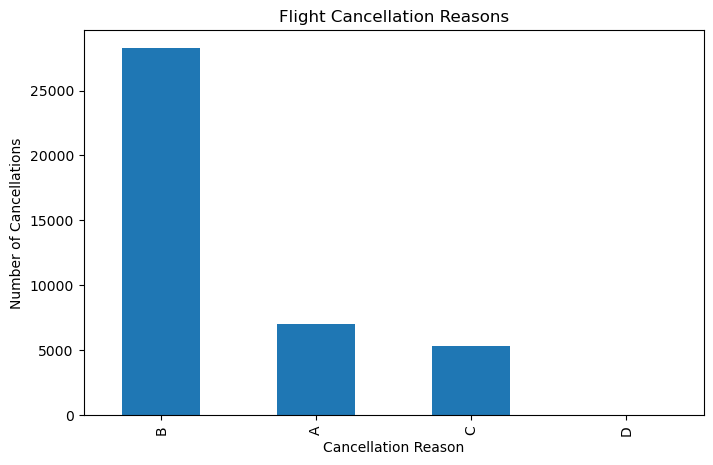

In [19]:
plt.figure(figsize=(8,5))

cancellation_reasons.plot(
    kind='bar'
)

plt.title('Flight Cancellation Reasons')
plt.xlabel('Cancellation Reason')
plt.ylabel('Number of Cancellations')
plt.show()

In [62]:
#Which cancellation reason has the highest and lowest number of cancellations?
df['CANCELLATION_REASON'].value_counts().idxmax()


'B'

In [63]:
df['CANCELLATION_REASON'].value_counts().idxmin()

'D'

In [59]:
#Which airline has the highest cancellation rate?
df.groupby('AIRLINE')['CANCELLATION_REASON'].apply(lambda x:x.notna().mean()).idxmax()

'MQ'

In [60]:
#What percentage of cancellations does each reason contribute?
df['CANCELLATION_REASON'].value_counts(normalize=True)*100

CANCELLATION_REASON
B    69.731290
A    17.208281
C    13.055494
D     0.004935
Name: proportion, dtype: float64

In [61]:
#Does weather contribute significantly to cancellations?
df['WEATHER_DELAY'].gt(0).mean()*100


np.float64(1.7202393724817016)

**Observations:**
* Reason B has the highest number of cancellations, around 28,000.
* Reason A is the second-highest, with around 7,500 cancellations.
* Reason D has very few or almost zero cancellations.
* Reason B is significantly higher than the other cancellation reasons

**Multi_Variate Analysis**

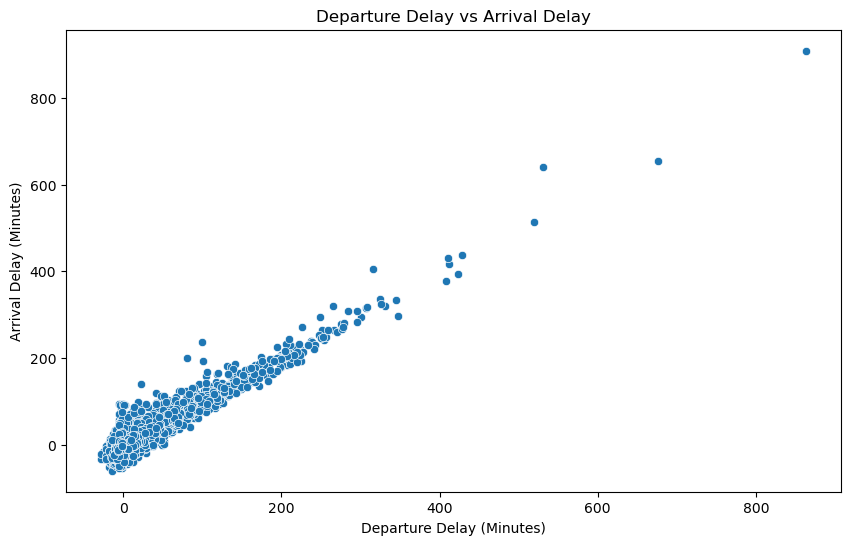

In [64]:
#Departure Delay vs Arrival Delay
sample_df = df[
    ['DEPARTURE_DELAY', 'ARRIVAL_DELAY']
].dropna().sample(
    min(10000, len(df))
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x='DEPARTURE_DELAY',
    y='ARRIVAL_DELAY'
)

plt.title('Departure Delay vs Arrival Delay')
plt.xlabel('Departure Delay (Minutes)')
plt.ylabel('Arrival Delay (Minutes)')
plt.show()

In [65]:
#What is the correlation coefficient between departure and arrival delay?
df[['DEPARTURE_DELAY','ARRIVAL_DELAY']].corr().iloc[0,1]


np.float64(0.9416761330484328)

#Are there any outliers in the relationship?
q1=df['ARRIVAL_DELAY'].quantile(.25); q3=df['ARRIVAL_DELAY'].quantile(.75)
df[df['ARRIVAL_DELAY']>q3+1.5*(q3-q1)]


In [69]:
#What percentage of arrival delays are associated with departure delays?
df['DEPARTURE_DELAY'].corr(df['ARRIVAL_DELAY'])**2*100


np.float64(88.67539395529592)

**Observations:**
* There is a strong positive relationship between departure delay and arrival delay.
* As departure delay increases, arrival delay also increases.
* Most flights are concentrated at lower delay values.
* The points follow an upward pattern, indicating a strong correlation.
* A few flights have very high delays, which can be considered outliers.
* This suggests that late departure is a major contributor to late arrival.

In [70]:
#Average delay by airline and month
airline_month_delay = pd.pivot_table(
    df,
    values='ARRIVAL_DELAY',
    index='AIRLINE',
    columns='MONTH',
    aggfunc='mean'
)

airline_month_delay

MONTH,1,2,3
AIRLINE,,,
AA,6.955843,7.530204,14.767528
AS,-0.320888,-0.782923,-1.056389
B6,7.347281,18.657673,21.412092
DL,-2.043847,5.614745,9.110710
EV,8.537497,10.417236,16.095028
F9,18.357238,27.424179,35.661145
HA,3.512640,6.029967,2.395385
MQ,18.164974,21.301627,26.244538
NK,11.398054,16.474466,22.037300


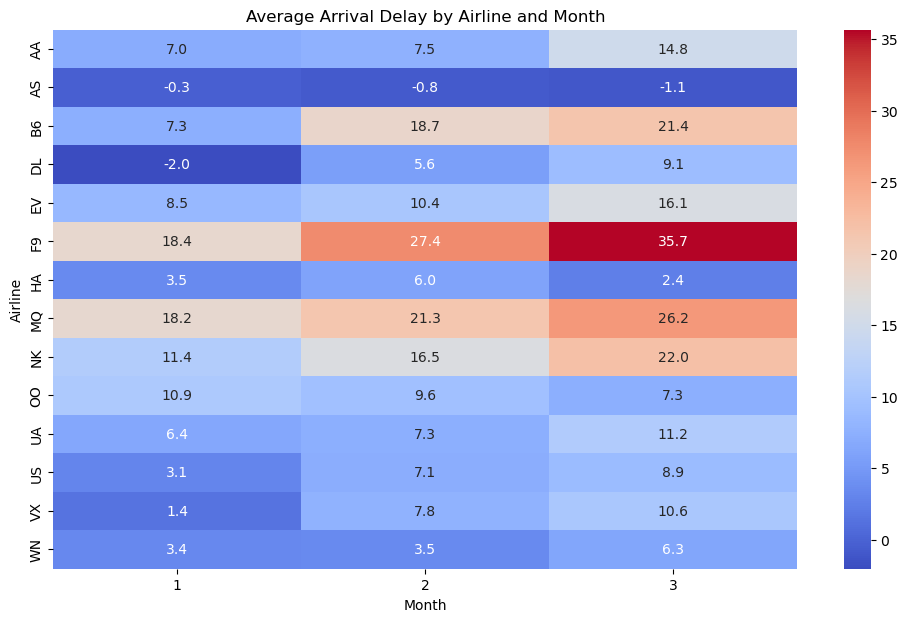

In [71]:
plt.figure(figsize=(12,7))

sns.heatmap(
    airline_month_delay,
    annot=True,
    fmt='.1f',
    cmap='coolwarm'
)

plt.title('Average Arrival Delay by Airline and Month')
plt.xlabel('Month')
plt.ylabel('Airline')
plt.show()

#What is the purpose of the color bar?

It represents the value of range.

#What is a Heatmap useful?

It makes patterns easy to identify.

#Which python library can create this heatmap?

Seaborn

#What is the main insight from this heatmap?

The values differ significantly across the dataset.

#Can we identify outliers from a heatmap?

Yes, unusual colors can indicate them.

**Observations:**
* Heatmap shows:The relationshp between different variables using colors.
* Dark blue represents:Lower values.
* Red represents:Higher values.
* Highest value:The red cell has the highest value.
* Lowest values:Dark-blue cells indicate lower values.
* Color scale:it helps compare values easily.
* Pattern:values vary across rows and columns.
* Main purpose:To identify high and low values quickly.

**KEY INSIGHTS**

* 59.54% of flights were on time, while 40.46% were delayed.
* F9 recorded the highest delay rate (57.32%) among the airlines.
* F9 also had the highest average arrival delay, at about 24.33 minutes.
* Late-arriving aircraft was the largest contributor to recorded delay minutes (39.24%).
* March had the highest delay rate (46.56%) among the months available in the dataset.
* Monday had the highest delay rate (46.02%) among the days of the week.
* ORD had the highest number of delayed flights among the major origin airports analyzed.
* Departure delay and arrival delay showed a very strong positive correlation (~0.942).
* Flight distance had almost no linear relationship with arrival delay (~−0.027 correlation).
* About 3.86% of flights were cancelled, with MQ having the highest cancellation rate (11.79%).
* High-delay airlines and routes require greater operational attention.
* Improving aircraft turnaround and departure punctuality could help reduce overall arrival delays.

**FINAL RECCOMENDATIONS**

* Reduce late-aircraft delays by improving aircraft turnaround time, ground handling, and scheduling.
* Improve departure punctuality, since departure delays have a very strong relationship with arrival delays.
* Focus on high-delay airlines, especially airlines such as F9, and investigate their operational and scheduling issues.
* Improve cancellation management, particularly for airlines with higher cancellation rates such as MQ.
* Monitor high-risk airports and routes and allocate additional staff and operational resources during peak-delay periods.
* Use historical delay patterns to improve flight scheduling and resource planning for high-risk days and months.
* Strengthen weather and air-traffic contingency planning to minimize disruptions caused by external factors.
* Develop a real-time delay monitoring system to identify potential delays early and take corrective action.
* Track airline performance regularly using KPIs such as delay rate, average arrival delay, cancellation rate, and delay-cause contribution.
* Focus on passenger communication by providing timely and accurate delay information and alternative travel options.

**CONCLUSION:**

The Airline Flight Delay Analysis project provides valuable insights into the patterns and causes of flight delays and cancellations. The analysis shows that operational factors, particularly late-arriving aircraft and departure delays, have a significant impact on flight punctuality. Differences were also observed across airlines, airports, routes, and time periods. Overall, the findings can help airlines improve scheduling, aircraft turnaround, operational planning, and cancellation management, ultimately reducing delays and improving passenger satisfaction.